<a href="https://colab.research.google.com/github/yuniecorn-dev/esaa_assignment/blob/main/ESAA_YB_WEEK10_study_0508.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ch5. 6~8 (p.337 ~ 362)

##5.6 규제 선형 모델 - 릿지, 라쏘, 엘라스틱넷

###규제 선형 모델의 개요

####좋은 회귀 모델
  - 데이터를 충분히 잘 설명하면서도
  - 지나치게 복잡하지 않아야 하며,
  - 과소적합과 과적합 사이의 균형이 중요
- 단순히 RSS(실제값과 예측값 차이)만 최소화하면
  - 회귀 계수가 커져 과적합이 발생하고 테스트 성능이 떨어질 수 있음.
- 이를 해결하기 위해
  - 비용 함수에 회귀 계수 크기에 대한 패널티(alpha × ||W||)를 추가하여 계수를 제어하는 정규화 방법을 사용

$$
\text{비용 함수 목표} =
\min \left( RSS(W) + \alpha \|W\|_2^2 \right)
$$

####alpha
  - 데이터 적합(RSS 최소화)과 회귀 계수 크기 제한(정규화) 사이의 균형을 조절하는 하이퍼파라미터
- alpha가 0이면
  - 정규화 효과가 없어 회귀 계수가 커질 수 있고, 학습 데이터에 과적합되기 쉬움.
- alpha가 매우 크면
  - 회귀 계수를 0에 가깝게 만들어 모델이 단순해지며, 과적합은 줄지만 너무 크면 과소적합이 발생할 수 있음.
####규제(Regularization)
  - alpha 값을 증가시키면
  - 회귀 계수 크기가 줄어들어 과적합을 완화
- L2 규제
  - 회귀 계수의 제곱값에 패널티를 주는 방식
  - 이를 적용한 모델이 **릿지(Ridge) 회귀**
- L1 규제
  - 회귀 계수의 절댓값에 패널티를 주는 방식
  - 중요하지 않은 계수를 0으로 만드는 **라쏘(Lasso) 회귀**에 사용

###릿지 회귀
- 보스턴 주택 가격 데이터의 X_data, y_target을 이용해 Ridge 모델을 학습
- cross_val_score()로 예측 성능을 평가

In [2]:
import pandas as pd
import numpy as np

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# Column names for the Boston dataset
feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
X_data = pd.DataFrame(data, columns=feature_names)
y_target = pd.Series(target, name='PRICE')

In [4]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

# alpha=10으로 설정해 릿지 회귀 수행.
ridge = Ridge(alpha=10)
neg_mse_scores = cross_val_score(ridge, X_data, y_target, scoring="neg_mean_squared_error", cv=5)
rmse_scores = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

print(' 5 folds의 개별 Negative MSE scores: ', np.round(neg_mse_scores, 3))
print(' 5 folds의 개별 RMSE scores: ', np.round(rmse_scores, 3))
print(' 5 folds의 평균 RMSE: {0:.3f}'.format(avg_rmse))

 5 folds의 개별 Negative MSE scores:  [-11.422 -24.294 -28.144 -74.599 -28.517]
 5 folds의 개별 RMSE scores:  [3.38  4.929 5.305 8.637 5.34 ]
 5 folds의 평균 RMSE: 5.518


- 릿지 회귀의 평균 RMSE(5.518)
  - 규제가 없는 LinearRegression의 RMSE(5.829)보다 낮아 더 좋은 예측 성능을 보임.
- alpha 값을 0 → 100으로 증가시키면
  - 규제가 강해져 회귀 계수 크기가 점점 작아짐.
- 다양한 alpha 값에 대해 RMSE와 회귀 계수 변화를 비교하면,
  - 규제가 모델 성능과 계수 크기에 어떤 영향을 주는지 확인 가능

In [5]:
# 릿지에 사용될 alpha 파라미터의 값을 정의
alphas = [0, 0.1, 1, 10, 100]

# alphas list 값을 반복하면서 alpha에 따른 평균 rmse를 구함.
for alpha in alphas:
  ridge = Ridge(alpha=alpha)

  # cross_val_score를 이용해 5 폴드의 평균 RMSE를 계산
  neg_mse_scores = cross_val_score(ridge, X_data, y_target, scoring="neg_mean_squared_error", cv=5)
  avg_rmse = np.mean(np.sqrt(-1 * neg_mse_scores))
  print('alpha {0}일 때 5 folds의 평균 RMSE: {1:.3f}'.format(alpha, avg_rmse))

alpha 0일 때 5 folds의 평균 RMSE: 5.829
alpha 0.1일 때 5 folds의 평균 RMSE: 5.788
alpha 1일 때 5 folds의 평균 RMSE: 5.653
alpha 10일 때 5 folds의 평균 RMSE: 5.518
alpha 100일 때 5 folds의 평균 RMSE: 5.330


####alpha 값의 변화에 따른 피처 회귀 계수의 값을 가로 막대 그래프로 시각화

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

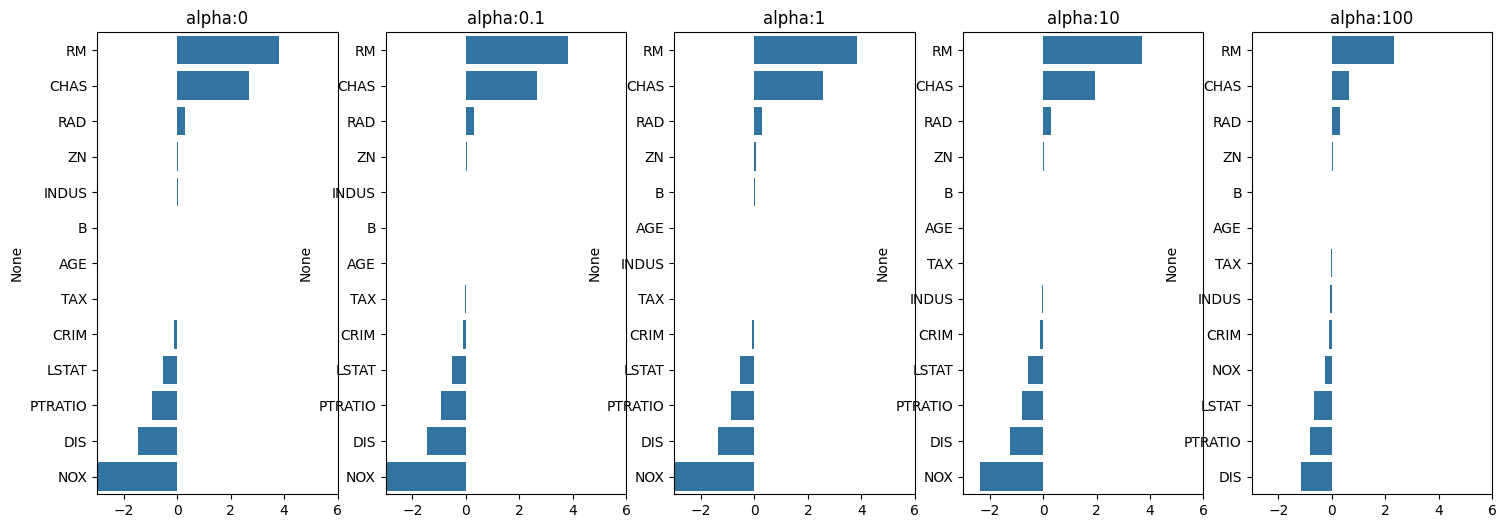

In [11]:
# 각 alpha에 따른 회귀 계수 값을 시각화하기 위해 5개의 열로 된 맷플롯립 축 생성
fig, axs = plt.subplots(figsize=(18,6), nrows=1, ncols=5)
# 각 alpha에 따른 회귀 계수 값을 데이터로 저장하기 위한 DataFrame 생성
coeff_df = pd.DataFrame()

# alphas 리스트 값을 차례로 입력해 회귀 계수 값 시각화 및 데이터 저장, pos는 axis의 위치 지정
for pos, alpha in enumerate(alphas):
  ridge = Ridge(alpha=alpha)
  ridge.fit(X_data, y_target)
  # alpha에 따른 피처별로 회귀 계수를 Series로 변환하고 이를 DataFrame의 칼럼으로 추가.
  coeff = pd.Series(data=ridge.coef_, index=X_data.columns)
  colname = 'alpha:'+str(alpha)
  coeff_df[colname] = coeff
  # 막대 그래프로 각 alpha 값에서의 회귀 계수를 시각화. 회귀 계수값이 높은 순으로 표현
  coeff = coeff.sort_values(ascending=False)
  axs[pos].set_title(colname)
  axs[pos].set_xlim(-3, 6)
  sns.barplot(x=coeff.values, y=coeff.index, ax=axs[pos])

# for 문 바깥에서 맷플롯립의 show 호출 및 alpha에 따른 피처별 회귀 계수를 DataFrame으로 표시
plt.show()

- alpha 값을 계속 증가시킬수록 회귀 계수 값은 지속적으로 작아짐.
- 특히 NOX 피처의 경우 alpha 값을 증가시킴에 따라 회귀 계수가 크게 작아지고 있음.

####DataFrame에 저장된 alpha 값의 변화에 따른 릿지 회귀 계수 값

In [13]:
ridge_alphas = [0, 0.1, 1, 10, 100]
sort_column = 'alpha:'+str(ridge_alphas[0])
coeff_df.sort_values(by=sort_column, ascending=False)

,alpha:0,alpha:0.1,alpha:1,alpha:10,alpha:100
RM,3.809865,3.818233,3.854000,3.702272,2.334536
CHAS,2.686734,2.670019,2.552393,1.952021,0.638335
RAD,0.306049,0.303515,0.290142,0.279596,0.315358
ZN,0.046420,0.046572,0.047443,0.049579,0.054496
INDUS,0.020559,0.015999,-0.008805,-0.042962,-0.052826
B,0.009312,0.009368,0.009673,0.010037,0.009393
AGE,0.000692,-0.000269,-0.005415,-0.010707,0.001212
TAX,-0.012335,-0.012421,-0.012912,-0.013993,-0.015856
CRIM,-0.108011,-0.107474,-0.104595,-0.101435,-0.102202
LSTAT,-0.524758,-0.525966,-0.533343,-0.559366,-0.660764


- alpha 값이 증가하면서 회귀 계수가 작아지고 있음.
- 릿지 회귀는 회귀 계수를 0으로 만들지는 않음.

###라쏘 회귀
- 회귀 계수의 절댓값에 패널티를 주는 L1 규제를 적용한 선형 회귀
- L1 규제는 중요하지 않은 회귀 계수를 0으로 만들어 불필요한 피처를 제거
- 따라서 과적합을 줄이는 동시에 자동으로 피처 선택(Feature Selection) 효과

- 효율적으로 비교하기 위해 get_linear_reg_eval() 함수를 만들어 릿지·라쏘·엘라스틱넷 모델의 성능과 회귀 계수를 공통 방식으로 평가

In [17]:
from sklearn.linear_model import Lasso, ElasticNet

# alpha값에 따른 회귀 모델의 폴드 평균 RMSE를 출력하고 회귀 계수값들을 DataFrame으로 반환
def get_linear_reg_eval(model_name, params=None, X_data_n=None, y_target_n=None,
                        verbose=True, return_coeff=True):
  coeff_df = pd.DataFrame()
  if verbose: print('######', model_name, '######')
  for param in params:
    if model_name == 'Ridge': model = Ridge(alpha=param)
    elif model_name == 'Lasso': model = Lasso(alpha=param)
    elif model_name == 'ElasticNet': model = ElasticNet(alpha=param, l1_ratio=0.7)
    neg_mse_scores = cross_val_score(model, X_data_n,
                                     y_target_n, scoring="neg_mean_squared_error", cv=5)
    avg_rmse = np.mean(np.sqrt(-1 * neg_mse_scores))
    print('alpha {0}일 때 5 폴드 세트의 평균 RMSE: {1:.3f}'.format(param, avg_rmse))
    # cross_val_score는 evaluation metric만 반환하므로 모델을 다시 학습하여 회귀 계수 추출

    model.fit(X_data_n, y_target_n)
    if return_coeff:
      # alpha에 따른 피처별 회귀 계수를 Series로 변환하고 이를 DataFrame의 칼럼으로 추가.
      coeff = pd.Series(data=model.coef_, index=X_data_n.columns)
      colname='alpha:'+str(param)
      coeff_df[colname] = coeff

  return coeff_df
#end of get_linear_regre_eval

In [18]:
# 라쏘에 사용된 alpha 파라미터 값을 정의하고 get_linear_reg_eval() 함수 호출
lasso_alphas = [0.07, 0.1, 0.5, 1, 3]
coeff_lasso_df = get_linear_reg_eval('Lasso', params=lasso_alphas, X_data_n=X_data, y_target_n=y_target)

###### Lasso ######
alpha 0.07일 때 5 폴드 세트의 평균 RMSE: 5.612
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 5.615
alpha 0.5일 때 5 폴드 세트의 평균 RMSE: 5.669
alpha 1일 때 5 폴드 세트의 평균 RMSE: 5.776
alpha 3일 때 5 폴드 세트의 평균 RMSE: 6.189


- alpha가 0.07일 때 5.612로 가장 좋은 평균 RMSE를 보여줌.
- 앞의 릿지 평균 5.518보다는 약간 떨어지는 수치지만, LinearRegression 평균인 5.829보다는 향상됨.

####alpha 값에 따른 피처별 회귀 계수

In [21]:
# 반환됨 coeff_lasso_df를 첫 번째 칼럼 순으로 내림차순 정렬해 회귀계수 DataFrame 출력
sort_column = 'alpha:'+str(lasso_alphas[0])
coeff_lasso_df.sort_values(by=sort_column, ascending=False)

,alpha:0.07,alpha:0.1,alpha:0.5,alpha:1,alpha:3
RM,3.789725,3.703202,2.498212,0.949811,0.000000
CHAS,1.434343,0.955190,0.000000,0.000000,0.000000
RAD,0.270936,0.274707,0.277451,0.264206,0.061864
ZN,0.049059,0.049211,0.049544,0.049165,0.037231
B,0.010248,0.010249,0.009469,0.008247,0.006510
NOX,-0.000000,-0.000000,-0.000000,-0.000000,0.000000
AGE,-0.011706,-0.010037,0.003604,0.020910,0.042495
TAX,-0.014290,-0.014570,-0.015442,-0.015212,-0.008602
INDUS,-0.042120,-0.036619,-0.005253,-0.000000,-0.000000
CRIM,-0.098193,-0.097894,-0.083289,-0.063437,-0.000000


- 라쏘 회귀에서는 alpha 값이 커질수록 일부 피처의 회귀 계수가 0으로 변함.
- 계수가 0이 된 피처는 회귀 식에서 제외되어 모델에 영향을 주지 않게 됨.

=> 라쏘는 과적합을 줄이는 동시에 자동으로 중요한 피처만 선택하는 효과를 제공



###엘라스틱넷 회귀
- 엘라스틱넷(Elastic Net) 회귀는 L1 규제(라쏘)와 L2 규제(릿지)를 함께 사용하는 회귀 방법
- 라쏘는 상관관계가 높은 피처 중 일부만 선택하고 나머지를 0으로 만드는 경향이 강한데, 엘라스틱넷은 L2 규제를 추가해 이를 완화
- 따라서 엘라스틱넷은 피처 선택 효과와 계수 안정성을 동시에 얻을 수 있는 모델
___
$$
\text{목적함수: }
\min_W \left( RSS(W) + \alpha_2 \|W\|_2^2 + \alpha_1 \|W\|_1 \right)
$$

여기서  
- \(RSS(W)\): 잔차 제곱합  
- \(\|W\|_2^2\): L2 정규화 (Ridge)  
- \(\|W\|_1\): L1 정규화 (Lasso)
___
- 사이킷런의 ElasticNet 클래스는 L1 규제와 L2 규제를 동시에 사용하는 엘라스틱넷 회귀를 구현
  - alpha: 전체 규제 강도(L1 + L2)
  - l1_ratio: 그중 L1 규제가 차지하는 비율
- l1_ratio = 0이면 Ridge, 1이면 Lasso와 동일

In [22]:
# 엘라스틱에 사용될 alpha 파라미터의 값들을 정의하고 get_linear_reg_eval() 함수 호출
# l1_ratio는 0.7로 고정
elastic_alphas = [0.07, 0.1, 0.5, 1, 3]
coeff_elastic_df = get_linear_reg_eval('ElasticNet', params=elastic_alphas,
                                       X_data_n=X_data, y_target_n=y_target)

###### ElasticNet ######
alpha 0.07일 때 5 폴드 세트의 평균 RMSE: 5.542
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 5.526
alpha 0.5일 때 5 폴드 세트의 평균 RMSE: 5.467
alpha 1일 때 5 폴드 세트의 평균 RMSE: 5.597
alpha 3일 때 5 폴드 세트의 평균 RMSE: 6.068


In [23]:
# 반환된 coeff_elastic_df를 첫 번째 칼럼순으로 내림차순 정렬해 회귀계수 DataFrame 출력
sort_column = 'alpha:'+str(elastic_alphas[0])
coeff_elastic_df.sort_values(by=sort_column, ascending=False)

,alpha:0.07,alpha:0.1,alpha:0.5,alpha:1,alpha:3
RM,3.574162,3.414154,1.918419,0.938789,0.000000
CHAS,1.330724,0.979706,0.000000,0.000000,0.000000
RAD,0.278880,0.283443,0.300761,0.289299,0.146846
ZN,0.050107,0.050617,0.052878,0.052136,0.038268
B,0.010122,0.010067,0.009114,0.008320,0.007020
AGE,-0.010116,-0.008276,0.007760,0.020348,0.043446
TAX,-0.014522,-0.014814,-0.016046,-0.016218,-0.011417
INDUS,-0.044855,-0.042719,-0.023252,-0.000000,-0.000000
CRIM,-0.099468,-0.099213,-0.089070,-0.073577,-0.019058
NOX,-0.175072,-0.000000,-0.000000,-0.000000,-0.000000


- 엘라스틱넷에서 alpha = 0.5일 때 RMSE 5.467로 가장 낮은 오차를 보여 예측 성능이 가장 좋았음.
- 엘라스틱넷은 라쏘보다 계수가 0이 되는 경우가 적어, 더 완만하게 피처를 선택하고 모델 안정성을 유지
- 릿지, 라쏘, 엘라스틱넷 중 최적의 방법은 데이터 특성에 따라 달라지며, 하이퍼파라미터 튜닝과 함께 데이터 정규화·인코딩이 매우 중요

###선형 회귀 모델을 위한 데이터 변환
- 선형 회귀 모델은 피처와 타깃 간에 선형 관계가 있고, 데이터가 정규 분포에 가까울수록 더 좋은 성능을 보임.
- 특히 타깃값이나 주요 피처가 왜곡(skewed)된 분포를 가지면 예측 성능이 떨어질 수 있음.
- 그래서 보통 스케일링이나 정규화 같은 전처리를 수행하지만, 항상 성능이 좋아지는 것은 아니며 데이터 분포가 심하게 왜곡된 경우에 주로 적용함.
___
- 피처 데이터는 보통 StandardScaler(평균 0, 분산 1)나 MinMaxScaler(0~1 범위)를 사용해 스케일링
- 필요에 따라 다항 변환이나 로그 변환을 추가로 적용하지만, 다항 변환은 피처 수 증가로 과적합 위험이 있음.
- 타깃값은 주로 로그 변환을 적용하며, 이는 왜곡된 분포를 완화하고 선형 회귀 성능을 개선하는 데 효과적인 방법
___
- 보스턴 주택 가격 데이터에 대해 StandardScaler, MinMaxScaler, 로그 변환(Log) 등 다양한 스케일링 방법을 적용한 뒤 RMSE로 성능을 비교
- get_scaled_data() 함수
  - method 인자로 변환 방식(Standard, MinMax, Log)을 선택하고, 필요 시 다항 특성(p_degree≤2)도 추가할 수 있도록 구성
- 로그 변환: np.log1p()
  - 언더플로우를 방지하며, 일반적인 로그 변환보다 안정적으로 데이터 분포를 변환

In [27]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures

# method는 표준 정규 분포 변환(Standard), 최댓값/최솟값 정규화(MinMax), 로그변환(Log) 결정
# p_degree는 다항식 특성을 추가할 때 적용. p_degree는 2이상 부여하지 않음.
def get_scaled_data(method='None', p_degree=None, input_data=None):
  if method == 'Standard':
    scaled_data = StandardScaler().fit_transform(input_data)
  elif method == 'MinMax':
    scaled_data = MinMaxScaler().fit_transform(input_data)
  else:
    scaled_data = input_data

  if p_degree != None:
    scaled_data = PolynomialFeatures(degree=p_degree, include_bias=False).fit_transform(scaled_data)

  return scaled_data

[피처데이터 변환 방법: get_linear_reg_eval()]
- (None, None): 아무런 변환을 하지 않은 원본 데이터
- ('Standard', None): 표준 정규 분포
- ('Standard', 2): 표준 정규 분포를 다시 2차 다항식 변환
- ('MinMax', None): 최솟값/최댓값 정규화
- ('MinMax', 2): 최솟값/최댓값 정규화를 다시 2차 다항식 변환
- ('Log', None): 로그 변환  

In [28]:
# Ridge의 alpha값을 다르게 적용하고 다양한 데이터 변환 방법에 따른 RMSE 추출.
alphas = [0.1, 1, 10, 100]

# 5개 방식으로 변환. 먼저 원본 그대로, 표준정규 분포, 표준 정규 분포+다항식 특성
# 최대/최소 정규화, 최대/최소 정규화+다항식 특성, 로그변환
scale_methods=[(None, None), ('Standard', None), ('Standard', 2),
               ('MinMax', None), ('MinMax', 2), ('Log', None)]
for scale_method in scale_methods:
  X_data_scaled = get_scaled_data(method=scale_method[0], p_degree=scale_method[1],
                                  input_data=X_data)
  print('\n## 변환 유형:{0}, Polynomial Degree:{1}'.format(scale_method[0], scale_method[1]))
  get_linear_reg_eval('Ridge', params=alphas, X_data_n=X_data_scaled,
                      y_target_n=y_target, verbose=False, return_coeff=False)


## 변환 유형:None, Polynomial Degree:None
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 5.788
alpha 1일 때 5 폴드 세트의 평균 RMSE: 5.653
alpha 10일 때 5 폴드 세트의 평균 RMSE: 5.518
alpha 100일 때 5 폴드 세트의 평균 RMSE: 5.330

## 변환 유형:Standard, Polynomial Degree:None
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 5.826
alpha 1일 때 5 폴드 세트의 평균 RMSE: 5.803
alpha 10일 때 5 폴드 세트의 평균 RMSE: 5.637
alpha 100일 때 5 폴드 세트의 평균 RMSE: 5.421

## 변환 유형:Standard, Polynomial Degree:2
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 8.827
alpha 1일 때 5 폴드 세트의 평균 RMSE: 6.871
alpha 10일 때 5 폴드 세트의 평균 RMSE: 5.485
alpha 100일 때 5 폴드 세트의 평균 RMSE: 4.634

## 변환 유형:MinMax, Polynomial Degree:None
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 5.764
alpha 1일 때 5 폴드 세트의 평균 RMSE: 5.465
alpha 10일 때 5 폴드 세트의 평균 RMSE: 5.754
alpha 100일 때 5 폴드 세트의 평균 RMSE: 7.635

## 변환 유형:MinMax, Polynomial Degree:2
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 5.298
alpha 1일 때 5 폴드 세트의 평균 RMSE: 4.323
alpha 10일 때 5 폴드 세트의 평균 RMSE: 5.185
alpha 100일 때 5 폴드 세트의 평균 RMSE: 6.538

## 변환 유형:Log, Polynomial Degree:None
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 5.788

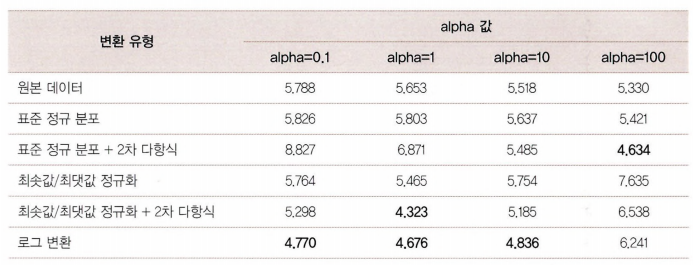

- 표준 정규화(StandardScaler)와 MinMax 정규화는 단독으로는 RMSE 개선 효과가 거의 없었음.
- 하지만 정규화 후 2차 다항 변환을 적용하면 일부 alpha 값에서 RMSE가 개선되었지만, 피처 증가와 계산 비용 때문에 실용성에는 한계가 있음.
- 반면 로그 변환은 여러 alpha 값에서 꾸준히 성능이 향상되어, 데이터 분포 왜곡이 심할 때 가장 효과적인 변환 방법임을 보여줌.



###5.7 로지스틱 회귀
- 로지스틱 회귀는 선형 회귀 모델을 기반으로 하지만, 분류 문제를 해결하는 알고리즘
- 선형 회귀처럼 가중치가 선형 결합으로 구성되므로 선형 모델에 속함.
- 하지만 예측값을 시그모이드(Sigmoid) 함수에 통과시켜 확률로 변환한 뒤, 그 확률을 기준으로 클래스를 결정한다는 점에서 차이가 있음.

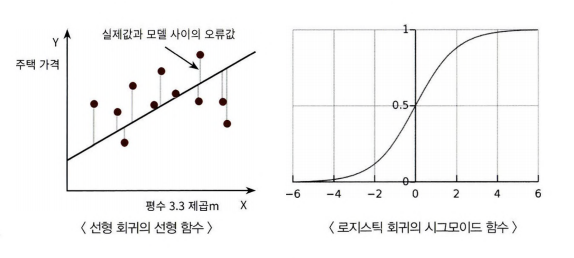

- 시그모이드 함수는 입력값이 아무리 커지거나 작아져도 출력값을 0과 1 사이로 제한하는 S자 형태의 함수
$$
y = \frac{1}{1 + e^{-z}}
$$
- 이러한 특성 때문에 로지스틱 회귀는 선형 회귀 결과를 시그모이드 함수에 통과시켜 확률 값으로 변환한 뒤 분류를 수행
- 예를 들어 종양 크기 같은 입력값을 기반으로 악성(1) 또는 정상(0)을 확률로 판단하는 방식으로 분류 문제에 적용됨.
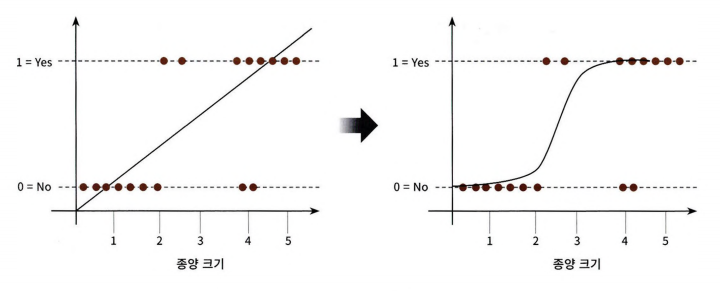

- 사이킷런은 로지스틱 회귀를 위해 LogisticRegression 클래스 제공
- solver 파라미터의 'lbfgs', 'liblinear', 'newton-cg', 'sag', 'saga', 값을 적용해서 최적화를 선택 가능
- 로지스틱 회귀의 solver 옵션들은 성능 차이가 크지 않지만, 일반적으로 lbfgs나 liblinear가 많이 사용

####위스콘신 유방암 데이터 세트 기반에서 로지스틱 회귀로 암 여부 판단하기 (LogisticRegression 클래스를 이용)

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

cancer = load_breast_cancer()

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# StandardScaler()로 평균이 0, 분산이 1로 데이터 분포도 변환
scaler = StandardScaler()
data_scaled = scaler.fit_transform(cancer.data)

X_train, X_test, y_train, y_test = train_test_split(data_scaled, cancer.target, test_size=0.3,
                                                    random_state=0)

In [31]:
from sklearn.metrics import accuracy_score, roc_auc_score

lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train) # 추가
lr_preds = lr_clf.predict(X_test)
lr_preds_proba = lr_clf.predict_proba(X_test)[:, 1]

print('{0:.3f},{1:.3f}'.format(accuracy_score(y_test, lr_preds),
roc_auc_score(y_test, lr_preds_proba)))

0.977,0.995


####서로 다른 solver 값으로 LogisticRegression 학습 및 성능 평가

In [32]:
solvers = ['lbfgs', 'liblinear', 'newton-cg', 'sag', 'saga']

# 여러 개의 solver 값별로 LogisticRegression 학습 후 성능 평가
for solver in solvers:
  lr_clf = LogisticRegression(solver=solver, max_iter=600)
  lr_clf.fit(X_train, y_train)
  lr_preds = lr_clf.predict(X_test)
  lr_preds_proba = lr_clf.predict_proba(X_test)[:,1]

  # accuracy와 roc_auc 측정
  print('solver:{0}, accuracy:{1:3}, roc_auc:{2:3f}'.format(solver,
                                                            accuracy_score(y_test, lr_preds),
                                                            roc_auc_score(y_test, lr_preds_proba)))

solver:lbfgs, accuracy:0.9766081871345029, roc_auc:0.994709
solver:liblinear, accuracy:0.9824561403508771, roc_auc:0.994709
solver:newton-cg, accuracy:0.9766081871345029, roc_auc:0.994709
solver:sag, accuracy:0.9824561403508771, roc_auc:0.994709
solver:saga, accuracy:0.9824561403508771, roc_auc:0.994709


- 로지스틱 회귀에서 solver에 따라 성능 차이는 일부 존재하지만, 데이터가 작으면 그 차이는 크지 않음. 예제에서는 liblinear가 약간 더 좋은 결과를 보이기도 함.
- 주요 하이퍼파라미터로는 penalty(규제 방식: L1, L2)와 C(규제 강도의 역수 1/alpha)가 있으며, C가 작을수록 규제가 강해짐.
- liblinear와 saga는 L1과 L2 규제를 모두 지원하지만, lbfgs, newton-cg, sag은 L2 규제만 지원하므로 solver 선택 시 규제 방식과 함께 고려해야 함.

In [34]:
from sklearn.model_selection import GridSearchCV

params={'solver':['liblinear', 'lbfgs'],
        'penalty':['l2', 'l1'],
        'C':[0.01, 0.1, 1, 5, 10]}

lr_clf = LogisticRegression()

grid_clf = GridSearchCV(lr_clf, param_grid=params, scoring='accuracy', cv=3)
grid_clf.fit(data_scaled, cancer.target)
print('최적 하이퍼 파라미터:{0}, 최적 평균 정확도:{1:.3f}'.format(grid_clf.best_params_,
                                                  grid_clf.best_score_))

최적 하이퍼 파라미터:{'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}, 최적 평균 정확도:0.979


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
15 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_solver

- GridSearchCV 결과에서 solver=liblinear, penalty=L2, C=0.1일 때 평균 정확도가 0.979로 가장 좋은 성능을 보였음.
- FitFailedWarning은 lbfgs가 L1 규제를 지원하지 않는데도 L1을 탐색 대상으로 넣어서 발생한 경고
- 로지스틱 회귀는 구조가 단순하고 계산이 빠르면서도 이진 분류 성능이 좋아 기본 분류 모델로 많이 사용되며, 희소한 텍스트 데이터 분류에도 효과적

###5.8 회귀 트리
- 선형 회귀: 회귀 계수를 선형 결합으로 표현해 최적의 회귀 함수를 찾는 방식
- 비선형 회귀: 회귀 계수의 관계가 비선형인 경우로, 함수 형태가 선형이 아닐 뿐 여전히 계수를 기반으로 예측을 수행
- 트리 기반 회귀(회귀 트리): 회귀 함수를 직접 사용하지 않고, 리프 노드에 있는 데이터의 평균값을 예측값으로 사용하는 방식

- 회귀 트리는 X 피처 값을 기준으로 데이터를 반복적으로 분할하면서 트리 구조를 만들어감.
- 분할 과정에서는 데이터의 균일도를 기준으로(분류 트리에서는 지니 계수 등) 최적의 분할 지점을 찾아 규칙 노드를 생성
- 최종적으로 더 이상 분할되지 않는 리프 노드에서는 해당 구간에 포함된 Y 값들의 평균을 계산해 예측값으로 사용
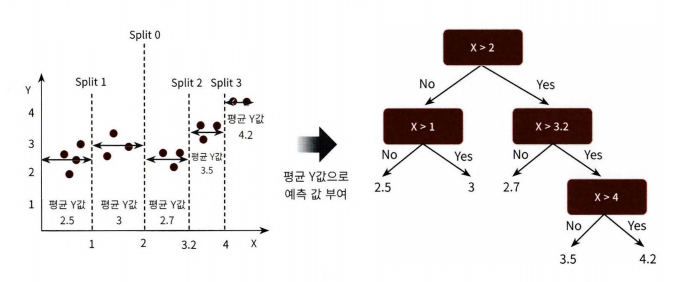

####보스턴 주택 가격 예측 수행 (RandomForestRegression 이용)

In [57]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load the boston dataset from the original source
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

boston_features = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
X_data = pd.DataFrame(data, columns=boston_features)
y_target = pd.Series(target, name='PRICE')

rf = RandomForestRegressor(random_state=0, n_estimators=1000)
neg_mse_scores = cross_val_score(rf, X_data, y_target, scoring="neg_mean_squared_error", cv = 5)
rmse_scores = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)
print('5 교차 검증의 개별 Negative MSE scores:', np.round(neg_mse_scores, 2))
print('5 교차 검증의 개별 RMSE scores :', np.round(rmse_scores, 2))
print('5 교차 검증의 평균 RMSE : {0:.3f}'.format(avg_rmse))

5 교차 검증의 개별 Negative MSE scores: [ -7.88 -13.14 -20.57 -46.23 -18.88]
5 교차 검증의 개별 RMSE scores : [2.81 3.63 4.54 6.8  4.34]
5 교차 검증의 평균 RMSE : 4.423


####GBM, XGBoost, LightGBM의 Regressor를 모두 이용해 예측 수행

In [58]:
def get_model_cv_prediction(model, X_data, y_target):
  neg_mse_scores=cross_val_score(model, X_data, y_target, scoring="neg_mean_squared_error", cv=5)
  rmse_scores = np.sqrt(-1 * neg_mse_scores)
  avg_rmse = np.mean(rmse_scores)
  print('##### ', model.__class__.__name__, ' #####')
  print(' 5 교차 검증의 평균 RMSE: {0:.3f} ',format(avg_rmse))

In [60]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

dt_reg = DecisionTreeRegressor(random_state=0, max_depth=4)
rf_reg = RandomForestRegressor(random_state=0, n_estimators=1000)
gb_reg = GradientBoostingRegressor(random_state=1000)
xgb_reg = XGBRegressor(n_estimators=1000)
lgb_reg = LGBMRegressor(n_estimators=1000, verbose=-1)

# 트리 기반의 회귀 모델을 반복하면서 평가 수행
models = [dt_reg, rf_reg, gb_reg, xgb_reg, lgb_reg]
for model in models:
  get_model_cv_prediction(model, X_data, y_target)

warnings.filterwarnings('ignore')

#####  DecisionTreeRegressor  #####
 5 교차 검증의 평균 RMSE: {0:.3f}  5.977957424580515
#####  RandomForestRegressor  #####
 5 교차 검증의 평균 RMSE: {0:.3f}  4.422538982804892
#####  GradientBoostingRegressor  #####
 5 교차 검증의 평균 RMSE: {0:.3f}  4.160593974196677
#####  XGBRegressor  #####
 5 교차 검증의 평균 RMSE: {0:.3f}  4.959252190267094
#####  LGBMRegressor  #####
 5 교차 검증의 평균 RMSE: {0:.3f}  4.646441191925675


####feature_importances_를 이용한 보스턴 주택 가격 모델의 피처별 중요도 시각화
- 회귀 트리 Regressor 클래스는 선형 회귀와 다른 처리 방식이므로 회기 계수를 제공하는 coef_ 속성이 없음.
- 대신 feature_importances_를 이용해 피처별 중요도 알 수 있음.

<Axes: xlabel='None', ylabel='None'>

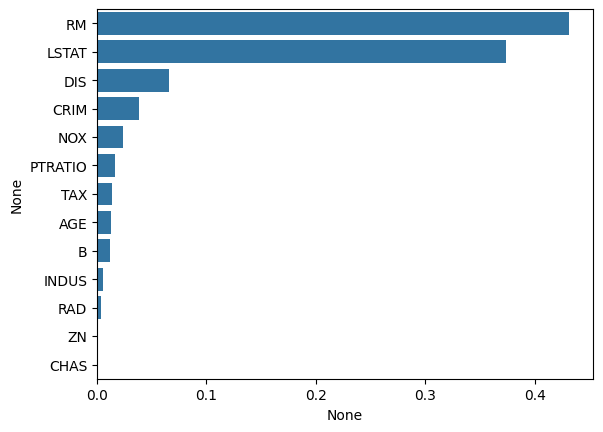

In [61]:
import seaborn as sns
%matplotlib inline

rf_reg = RandomForestRegressor(n_estimators=1000)

# 앞 예제에서 만들어진 X_data, y_target 데이터 세트를 적용해 학습합니다.
rf_reg.fit(X_data, y_target)

feature_series = pd.Series(data=rf_reg.feature_importances_, index=X_data.columns)
feature_series = feature_series.sort_values(ascending=False)
sns.barplot(x=feature_series, y=feature_series.index, orient='h')

- 회귀 트리의 동작을 선형 회귀와 비교하기 위해 보스턴 주택 데이터에서 RM(평균 방 개수) 하나만 사용해 PRICE를 예측
- 전체 데이터를 100개만 샘플링하고 RM과 PRICE만 추출하여 2차원 평면에서 시각화할 수 있도록 구성
- 이렇게 만든 산점도를 기반으로 선형 회귀와 회귀 트리의 예측선 차이를 비교하며, 특히 max_depth 변화에 따른 트리 모델의 복잡도 변화를 확인

(100, 2)


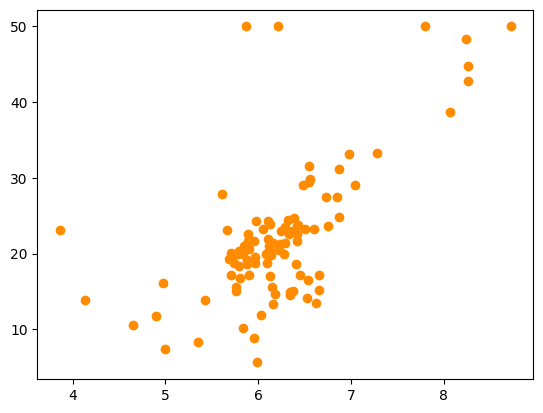

In [63]:
bostonDF = X_data.copy()
bostonDF['PRICE'] = y_target

bostonDF_sample = bostonDF[['RM', 'PRICE']]
bostonDF_sample = bostonDF_sample.sample(n=100, random_state=0)
print(bostonDF_sample.shape)

plt.figure()
plt.scatter(bostonDF_sample.RM, bostonDF_sample.PRICE, c="darkorange")
plt.show()

In [65]:
import numpy as np
from sklearn.linear_model import LinearRegression

# 선형 회귀와 결정 트리 기반의 Regressor 생성. DecisionTreeRegressor의 max_depth는 각각 2, 7
lr_reg = LinearRegression()
rf_reg2 = DecisionTreeRegressor(max_depth=2)
rf_reg7 = DecisionTreeRegressor(max_depth=7)

# 실제 예측을 적용할 테스트용 데이터 세트를 4.5~8.5까지의 100개 데이터 세트로 생성.
X_test = np.arange(4.5, 8.5, 0.04).reshape(-1, 1)

# 보스턴 주택 가격 데이터에서 시각화를 위해 피처는 RM만, 그리고 결정 데이터인 PRICE 추출
X_feature = bostonDF_sample['RM'].values.reshape(-1,1)
y_target = bostonDF_sample['PRICE'].values.reshape(-1,1)

# 학습과 예측 수행.
lr_reg.fit(X_feature, y_target)
rf_reg2.fit(X_feature, y_target)
rf_reg7.fit(X_feature, y_target)

pred_lr = lr_reg.predict(X_test)
pred_rf2 = rf_reg2.predict(X_test)
pred_rf7 = rf_reg7.predict(X_test)

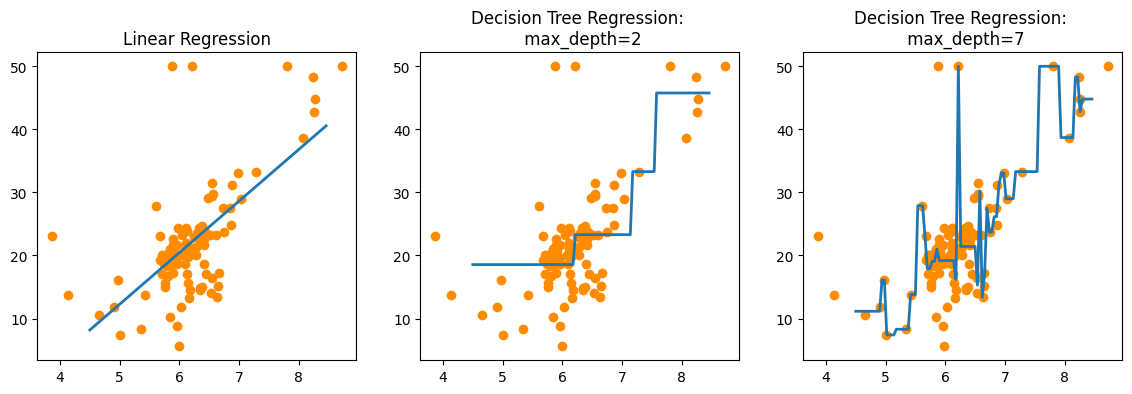

In [69]:
fig, (ax1, ax2, ax3) = plt.subplots(figsize=(14, 4), ncols=3)

# X축 값을 4.5 ~ 8.5로 변환하며 입력했을 때 선형 회귀와 결정 트리 회귀 예측선 시각화
# 선형 회귀로 학습된 모델 회귀 예측선
ax1.set_title('Linear Regression')
ax1.scatter(bostonDF_sample.RM, bostonDF_sample.PRICE, c="darkorange")
ax1.plot(X_test, pred_lr, label="linear", linewidth=2)

# DecisionTreeRegressor의 max_depth를 2로 했을 때 회귀 예측선
ax2.set_title("Decision Tree Regression: \n max_depth=2")
ax2.scatter(bostonDF_sample.RM, bostonDF_sample.PRICE, c="darkorange")
ax2.plot(X_test, pred_rf2, label="max_depth:2", linewidth=2)

# DecisionTreeRegressor의 max_depth를 7로 했을 때 회귀 예측선
ax3.set_title("Decision Tree Regression: \n max_depth=7")
ax3.scatter(bostonDF_sample.RM, bostonDF_sample.PRICE, c="darkorange")
ax3.plot(X_test, pred_rf7, label="max_depth:7", linewidth=2)

- 선형 회귀는 전체 데이터의 관계를 하나의 직선으로 표현하지만, 회귀 트리는 데이터를 구간별로 나눠 계단 형태의 예측선을 만듦.
- 회귀 트리는 분할을 통해 각 구간의 평균값으로 예측하므로 비선형적인 패턴도 표현할 수 있음.
- 하지만 max_depth=7처럼 깊이가 커지면 이상치까지 학습하게 되어 모델이 복잡해지고 과적합이 발생할 가능성이 높아짐.